# Deep fake classification with transfer learning: EfficientNet base

## Imports

In [1]:
#Graphics
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

#Keras
from keras.models import Model
from keras import Input, layers, optimizers, callbacks

from keras.utils import image_dataset_from_directory

#Pretrained model for transfer learning
from keras.applications.efficientnet import EfficientNetB3, preprocess_input

#Saving models
import joblib

2026-03-14 14:20:56.851215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773498057.077294      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773498057.134078      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773498057.637864      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773498057.637904      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773498057.637907      55 computation_placer.cc:177] computation placer alr

## Location of the data

In [2]:
#Lightweight dataset
train_data_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/"
val_data_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/"
test_data_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/"

## Parameters

In [3]:
BATCH_SIZE = 256
IMAGE_SIZE = (256, 256)
IMAGE_HEIGHT = IMAGE_SIZE[0]
IMAGE_WIDTH = IMAGE_SIZE[1]
NUM_CHANNELS = 3
SEED = 42
LEARNING_RATE = 0.001
PATIENCE = 5
EPOCHS = 40

## Creating datasets from directories

In [4]:
train_ds = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)


val_ds = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

test_ds = image_dataset_from_directory(
    test_data_dir,
    labels="inferred",
    label_mode="binary",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 100000 files belonging to 2 classes.


I0000 00:00:1773498232.034196      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773498232.040176      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['fake', 'real']


In [7]:
def initialize_model():

    ######################
    ###  Architecture  ###
    ######################

    #Input
    inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, NUM_CHANNELS))

    #Normalization
    x = layers.Rescaling(1./255)(inputs)

    #CNN
    x = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), padding='same')(x)

    x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), padding='same')(x)

    x = layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), padding='same')(x)

    x = layers.Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), padding='same')(x)


    x = layers.Flatten()(x)

    #Dense layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    ################
    ##  Compiler  ##
    ################
    adam = optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy', 'recall', 'precision'])

    return model

In [8]:
model = initialize_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,785,473 (33.51 MB)

 Trainable params: 8,785,473 (33.51 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# MODEL = 'dfake_efficientnet.keras'

# modelCheckpoint = callbacks.ModelCheckpoint(MODEL,
#                                             monitor="val_loss",
#                                             verbose=0,
#                                             save_best_only=True)

LRreducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.1,
                                        patience=3,
                                        verbose=1,
                                        min_lr=0)

EarlyStopper = callbacks.EarlyStopping(monitor='val_loss',
                                       patience=PATIENCE,
                                       verbose=0,
                                       restore_best_weights=True)

In [10]:
%%time
history = model.fit(train_ds,
                    epochs=EPOCHS,
                    validation_data=val_ds,
                    callbacks=[LRreducer, EarlyStopper],
                    verbose=1)

Epoch 1/40


I0000 00:00:1773498359.501569     131 service.cc:152] XLA service 0x78c5b0804e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773498359.501604     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773498359.501608     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773498360.169540     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-14 14:26:07.307477: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.13 = (f32[256,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,32,128,128]{3,2,1,0} %bitcast.8884, f32[64,32,3,3]{3,2,1,0} %bitcast.8038, f32[64]{0} %bitcast.8944), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv2d_1_2/convolution" sourc

390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.6286 - loss: 0.6344 - precision: 0.6312 - recall: 0.6006

2026-03-14 14:30:36.591562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 14:30:36.842145: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 14:30:41.212925: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 14:30:41.584284: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.5 = (f32[160,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[160,64,128,128]{3,2,1,0} %bitcast.8948, f32[64,32,3,3]{3,2,1,0} %bitcast.8038), window

391/391 ━━━━━━━━━━━━━━━━━━━━ 361s 824ms/step - accuracy: 0.6289 - loss: 0.6340 - precision: 0.6315 - recall: 0.6011 - val_accuracy: 0.7886 - val_loss: 0.4638 - val_precision: 0.7531 - val_recall: 0.8587 - learning_rate: 0.0010
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 243s 620ms/step - accuracy: 0.8025 - loss: 0.4335 - precision: 0.7974 - recall: 0.8099 - val_accuracy: 0.8678 - val_loss: 0.3111 - val_precision: 0.8254 - val_recall: 0.9330 - learning_rate: 0.0010
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 243s 620ms/step - accuracy: 0.8799 - loss: 0.2890 - precision: 0.8717 - recall: 0.8904 - val_accuracy: 0.9184 - val_loss: 0.2071 - val_precision: 0.9325 - val_recall: 0.9021 - learning_rate: 0.0010
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 243s 622ms/step - accuracy: 0.9244 - loss: 0.1942 - precision: 0.9190 - recall: 0.9304 - val_accuracy: 0.9300 - val_loss: 0.1765 - val_precision: 0.9596 - val_recall: 0.8978 - learning_rate: 0.0010
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 622ms/step - a

In [11]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

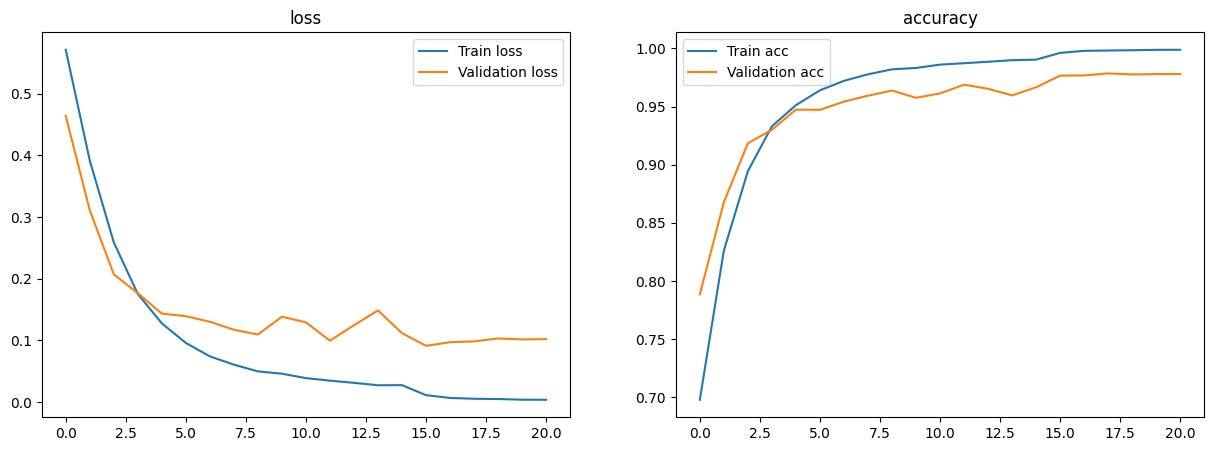

In [12]:
plot_history(history)

In [13]:
model.evaluate(test_ds)

79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 347ms/step - accuracy: 0.9767 - loss: 0.0856 - precision: 0.9764 - recall: 0.9766


[0.09061093628406525,
 0.9759500026702881,
 0.9740999937057495,
 0.9777175784111023]

In [14]:
joblib.dump(model, "/kaggle/working/cnn_full_dataset.joblib")

['/kaggle/working/cnn_full_dataset.joblib']